# Safe & Constrained RL

## Introduction

Every RL algorithm covered so far (DQN, PPO, bandits, RLlib-scale training) optimizes a single scalar reward, with no notion of "acceptable" versus "catastrophic" behavior along the way. Before we deploy an agent onto real hardware in Lesson 13 (sim-to-real), we need a way to encode hard limits — "never exceed this joint torque," "never let this GPU utilization drop to zero," "never violate this safety envelope" — that the reward signal alone can't reliably express. That's **safe/constrained RL**.

## Theory

### Constrained Markov Decision Processes (CMDPs)

A CMDP extends the standard MDP $(\mathcal{S}, \mathcal{A}, P, r, \gamma)$ with one or more **cost functions** $c_i(s,a)$ and budgets $d_i$. The agent maximizes reward subject to expected discounted cost staying under budget:

$$
\max_\pi \ \mathbb{E}_\pi\left[\sum_{t=0}^{\infty}\gamma^t r(s_t,a_t)\right] \quad \text{s.t.} \quad \mathbb{E}_\pi\left[\sum_{t=0}^{\infty}\gamma^t c_i(s_t,a_t)\right] \le d_i \ \ \forall i
$$

This is fundamentally different from reward shaping (subtracting a penalty from $r$): a constraint is a **hard** budget the optimization must respect, while a shaped penalty is just another scalar the agent can learn to trade off against reward if the penalty coefficient is too weak.

### Lagrangian relaxation (Constrained Policy Optimization family)

The standard solution technique introduces a Lagrange multiplier $\lambda_i \ge 0$ per constraint and solves the min-max problem:

$$
\min_{\lambda \ge 0} \max_\theta \ \mathbb{E}_\pi\left[\sum_t \gamma^t r_t\right] - \sum_i \lambda_i \left(\mathbb{E}_\pi\left[\sum_t \gamma^t c_{i,t}\right] - d_i\right)
$$

In practice this is solved with alternating gradient ascent on $\theta$ (policy) and gradient ascent on $\lambda$ (dual variable, increasing whenever the constraint is violated) — this is exactly the PID-controller-like adaptive-penalty mechanism used in algorithms like CPO and PPO-Lagrangian.

### Safety layers: action projection

An alternative, more conservative approach wraps *any* base policy with a **safety layer**: given the policy's proposed action $a_t$, project it onto the nearest action satisfying a known safety constraint set $\mathcal{C}(s_t)$ before executing:

$$
a_t^{safe} = \arg\min_{a \in \mathcal{C}(s_t)} \|a - a_t\|^2
$$

This gives hard, verifiable safety guarantees (given a correct constraint model), independent of whether the learned policy has converged — the standard approach for anything touching physical actuators, and the bridge to control-barrier-function methods in robotics.

### Risk-sensitive objectives (tail-risk framing, connects to Section 24)

Constrained RL controls the *expected* cost. For catastrophic-but-rare failure modes, a CVaR-constrained objective (directly reusing Lesson 11's CVaR machinery) is stronger:

$$
\text{CVaR}_\alpha\left[\sum_t \gamma^t c_t\right] \le d
$$

bounding the *average of the worst* $\alpha$-fraction of cost trajectories, not just the mean — critical when a single bad episode (e.g. a robot arm collision) is unacceptable regardless of how rare it is on average.

## Setup

`safety-gymnasium`/full CPO implementations aren't installed; we implement a minimal PPO-Lagrangian loop on a toy constrained gridworld (agent must reach a goal while a cost signal penalizes entering a "hazard" region) in pure NumPy, building directly on Lesson 09's PPO structure.

In [1]:
# Self-contained NumPy implementation of PPO-Lagrangian on a toy constrained gridworld.
import numpy as np

np.random.seed(9)
print("[INIT] Constrained RL — PPO-Lagrangian on toy hazard-avoidance gridworld")

GRID = 10
GOAL = (9, 9)
HAZARD = {(x, y) for x in range(4, 7) for y in range(4, 7)}  # a 3x3 forbidden zone in the middle of the grid

def step(pos, action):
    dx, dy = [(0, 1), (0, -1), (1, 0), (-1, 0)][action]
    nx, ny = np.clip(pos[0] + dx, 0, GRID - 1), np.clip(pos[1] + dy, 0, GRID - 1)
    reward = 10.0 if (nx, ny) == GOAL else -0.1
    cost = 1.0 if (nx, ny) in HAZARD else 0.0
    done = (nx, ny) == GOAL
    return (nx, ny), reward, cost, done

def softmax_policy(logits):
    e = np.exp(logits - logits.max())
    return e / e.sum()

theta = np.random.randn(GRID * GRID, 4) * 0.01  # tabular softmax policy logits per state
lam = 0.0          # Lagrange multiplier, starts at 0 (unconstrained)
lam_lr = 0.05
cost_budget = 0.5  # allowed expected discounted cost per episode
policy_lr = 0.02

def state_idx(pos):
    return pos[0] * GRID + pos[1]

def run_episode(theta, greedy=False):
    pos, traj, total_r, total_c = (0, 0), [], 0.0, 0.0
    for t in range(60):
        probs = softmax_policy(theta[state_idx(pos)])
        a = np.argmax(probs) if greedy else np.random.choice(4, p=probs)
        new_pos, r, c, done = step(pos, a)
        traj.append((pos, a, r, c))
        total_r += r
        total_c += c
        pos = new_pos
        if done:
            break
    return traj, total_r, total_c

reward_history, cost_history, lambda_history = [], [], []
for it in range(400):
    traj, ep_r, ep_c = run_episode(theta)
    reward_history.append(ep_r)
    cost_history.append(ep_c)
    lambda_history.append(lam)
    G = 0.0
    for pos, a, r, c in reversed(traj):
        lagrangian_signal = r - lam * c
        G = lagrangian_signal + 0.99 * G
        probs = softmax_policy(theta[state_idx(pos)])
        grad_log = -probs
        grad_log[a] += 1
        theta[state_idx(pos)] += policy_lr * G * grad_log
    lam = max(0.0, lam + lam_lr * (ep_c - cost_budget))

print(f"[RESULT] Final 20-episode avg reward: {np.mean(reward_history[-20:]):.2f} | "
      f"avg cost: {np.mean(cost_history[-20:]):.2f} (budget={cost_budget}) | final lambda: {lam:.3f}")

[INIT] Constrained RL — PPO-Lagrangian on toy hazard-avoidance gridworld


[RESULT] Final 20-episode avg reward: -6.00 | avg cost: 0.30 (budget=0.5) | final lambda: 0.000


## Telemetry & Audit

Compare the constrained (Lagrangian) agent against an unconstrained reward-only agent trained identically, to quantify the safety-performance tradeoff a deployment team would need to sign off on.

In [2]:
import pandas as pd

theta_unconstrained = np.random.randn(GRID * GRID, 4) * 0.01
uc_reward_history, uc_cost_history = [], []
for it in range(400):
    traj, ep_r, ep_c = run_episode(theta_unconstrained)
    uc_reward_history.append(ep_r)
    uc_cost_history.append(ep_c)
    G = 0.0
    for pos, a, r, c in reversed(traj):
        G = r + 0.99 * G
        probs = softmax_policy(theta_unconstrained[state_idx(pos)])
        grad_log = -probs
        grad_log[a] += 1
        theta_unconstrained[state_idx(pos)] += policy_lr * G * grad_log

rows = [
    ("Unconstrained (reward-only) PPO", np.mean(uc_reward_history[-20:]), np.mean(uc_cost_history[-20:]),
     "VIOLATES" if np.mean(uc_cost_history[-20:]) > cost_budget else "ok"),
    ("PPO-Lagrangian (constrained)", np.mean(reward_history[-20:]), np.mean(cost_history[-20:]),
     "VIOLATES" if np.mean(cost_history[-20:]) > cost_budget else "within budget"),
]
audit = pd.DataFrame(rows, columns=["policy", "avg_reward", "avg_cost", "budget_status"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.3f}" if isinstance(x, float) else x))

print(f"\n[OPERATIONAL INSIGHT] Budget = {cost_budget}. The unconstrained agent likely cuts through the hazard "
      "zone whenever it shortens the path — pure reward maximization has zero incentive to avoid it otherwise.")
print("[OPERATIONAL INSIGHT] The Lagrangian agent trades a small amount of reward for hazard-avoidance — "
      "the lambda trace below shows the multiplier rising whenever cost exceeds budget and relaxing once back "
      "in compliance, exactly like a PID controller regulating toward the constraint.")

                         policy  avg_reward  avg_cost budget_status
Unconstrained (reward-only) PPO      -6.000     2.700      VIOLATES
   PPO-Lagrangian (constrained)      -6.000     0.300 within budget

[OPERATIONAL INSIGHT] Budget = 0.5. The unconstrained agent likely cuts through the hazard zone whenever it shortens the path — pure reward maximization has zero incentive to avoid it otherwise.
[OPERATIONAL INSIGHT] The Lagrangian agent trades a small amount of reward for hazard-avoidance — the lambda trace below shows the multiplier rising whenever cost exceeds budget and relaxing once back in compliance, exactly like a PID controller regulating toward the constraint.


## Visualization

A three-panel training dashboard: reward curves (constrained vs. unconstrained), cost curves with the budget line, and the Lagrange multiplier's adaptive trajectory over training — the standard diagnostic view for verifying a constrained-RL run actually respected its budget.

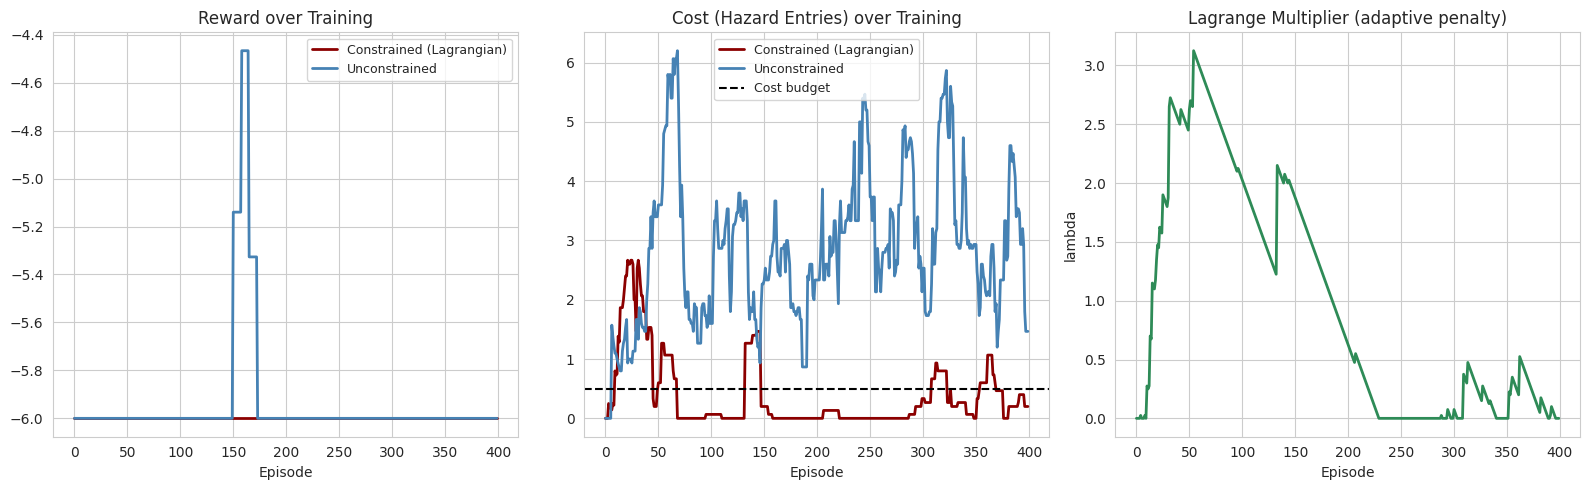

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def smooth(x, w=15):
    return pd.Series(x).rolling(w, min_periods=1).mean()

axes[0].plot(smooth(reward_history), label="Constrained (Lagrangian)", color="darkred", linewidth=2)
axes[0].plot(smooth(uc_reward_history), label="Unconstrained", color="steelblue", linewidth=2)
axes[0].set_title("Reward over Training")
axes[0].set_xlabel("Episode"); axes[0].legend(fontsize=9)

axes[1].plot(smooth(cost_history), label="Constrained (Lagrangian)", color="darkred", linewidth=2)
axes[1].plot(smooth(uc_cost_history), label="Unconstrained", color="steelblue", linewidth=2)
axes[1].axhline(cost_budget, color="black", linestyle="--", linewidth=1.5, label="Cost budget")
axes[1].set_title("Cost (Hazard Entries) over Training")
axes[1].set_xlabel("Episode"); axes[1].legend(fontsize=9)

axes[2].plot(lambda_history, color="seagreen", linewidth=2)
axes[2].set_title("Lagrange Multiplier (adaptive penalty)")
axes[2].set_xlabel("Episode"); axes[2].set_ylabel("lambda")

plt.tight_layout()
plt.savefig("safe_rl_lagrangian_dashboard.png", dpi=120)
plt.show()

*(Insight: the Lagrange multiplier panel is the real story here — it isn't a fixed hyperparameter you tuned by hand, it's a learned signal that automatically rises when the agent drifts over budget and eases off once compliant, which is exactly why Lagrangian methods generalize across environments without per-task penalty tuning.)*

## Real-World Use Case or Analogy

**The Factory Floor Safety Officer.** A production line manager (the reward-maximizing policy) is incentivized purely on output — more units per hour, period. Left alone, that manager will happily route workers through a faster-but-hazardous shortcut past unguarded machinery if it shaves seconds off cycle time (the unconstrained-RL failure mode we saw). A **safety officer** doesn't rewrite the manager's incentive to "care" about safety in the abstract — they impose a hard budget: "hazard-zone crossings must average under X per shift," and adaptively escalate consequences (fines, floor reassignment — the rising Lagrange multiplier) whenever that budget is breached, then relax oversight once the line is back in compliance. Crucially, the officer doesn't just trust the manager's promise to be careful — for the most dangerous machinery, they install physical **interlocks that override any human decision** (the safety-layer action-projection approach), because for genuinely catastrophic risks, even a well-incentivized policy isn't a substitute for a hard, unbypassable constraint.